In [2]:
import pandas as pd

df = pd.read_csv('logbook_assignment1.csv')
df.head(10)

C:\Users\pabal\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (3,6) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...
5,Oct 23 2021,Oct 23 2021,"147,567",3.413,$3.739,$12.76,29.0,NaN,https://www.somewebsite.com/volkswagen/passat/...
6,Nov 20 2021,Dec 12 2021,"105,929",9.044,$4.639,$41.96,29.5,NaN,https://www.somewebsite.com/mazda/3_sport/2010...
7,Jan 20 2022,Jan 20 2022,"59,475",14.962,$2.929,$43.82,27.3,NaN,https://www.somewebsite.com/subaru/forester/20...
8,NaN,Apr 16 2018,"137,562",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/kianival/2009/789684
9,NaN,Nov 29 2020,"99,296",2.710,$1.999,$5.42,0.0,NaN,https://www.somewebsite.com/lexus/rx350/2012/8...


#  1 Data Cleaning

## 1.1 Date Fields

### Question 1: Percentage of invalid `date_fueled` entries
We attempt to parse `date_fueled` using the expected format (`%b %d %Y`, e.g. "Apr 7 2022"). 
Any value that doesn't match this format (e.g. free-text maintenance notes) is coerced to `NaT`.
We then compute what percentage of the column is `NaT`.

In [3]:
parsed = pd.to_datetime(df['date_fueled'], format='%b %d %Y', errors='coerce')
percent_invalid = parsed.isna().mean() * 100
print(percent_invalid)

11.678738924306518


### Question 2: Filling invalid `date_fueled` using `date_captured`
Where `date_fueled` could not be parsed but `date_captured` is a valid date, 
we use `date_captured` as a proxy for the fueling date, since it is likely close in time.

In [4]:
parsed_captured = pd.to_datetime(df['date_captured'], format='%b %d %Y', errors='coerce')

df['date_fueled_clean'] = parsed.copy()

mask = parsed.isna() & parsed_captured.notna()
df.loc[mask, 'date_fueled_clean'] = parsed_captured[mask]

print(f"Rows filled using date_captured: {mask.sum()}")

Rows filled using date_captured: 137210


### Question 3: Convert `date_fueled` to proper date format
`date_fueled_clean` was already converted to datetime type as part of the parsing 
in Questions 1–2, with invalid entries set to `NaT`. We confirm this below.


In [5]:
print(df['date_fueled_clean'].dtype)
print(df['date_fueled_clean'].isna().sum())

datetime64[ns]
0


### Question 4: Remove invalid date ranges
Some `date_fueled_clean` values may be in the future or earlier than 2005. We set these to `NaT`.

In [6]:
today = pd.Timestamp.today()

future_mask = df['date_fueled_clean'] > today
too_old_mask = df['date_fueled_clean'] < '2005-01-01'

print(f"Future dates: {future_mask.sum()}")
print(f"Dates before 2005: {too_old_mask.sum()}")

df.loc[future_mask | too_old_mask, 'date_fueled_clean'] = pd.NaT

Future dates: 12
Dates before 2005: 558


### Question 5: Distribution of fueling dates
We plot a histogram of `date_fueled_clean` to see how fill-up entries are 
distributed over time.

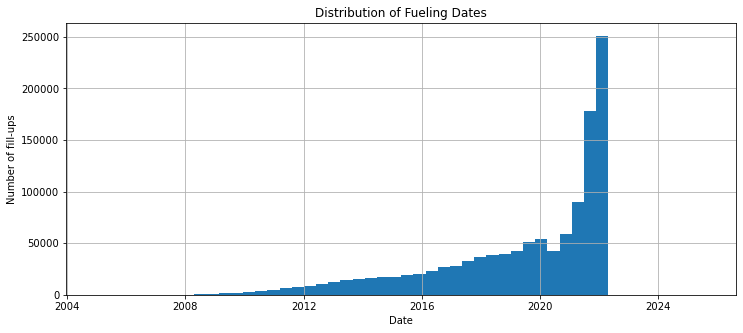

In [7]:
import matplotlib.pyplot as plt

df['date_fueled_clean'].hist(bins=50, figsize=(12, 5))
plt.xlabel('Date')
plt.ylabel('Number of fill-ups')
plt.title('Distribution of Fueling Dates')
plt.show()

## 1.2 Numeric Fields

### Question 1: Percentage of missing entries
We check what percentage of `gallons`, `miles`, and `odometer` are missing (NaN).

In [8]:
for col in ['gallons', 'miles', 'odometer']:
    pct_missing = df[col].isna().mean() * 100
    print(f"{col}: {pct_missing:.2f}% missing")

gallons: 6.32% missing
miles: 87.55% missing
odometer: 12.70% missing


### Question 3: Convert numeric fields to float
`gallons`, `miles`, `odometer`, and `mpg` are read in as text (object dtype), 
and some contain commas (thousands separators) or leading/trailing whitespace. We clean and convert these to proper float types so that Question 2 can work. 

In [9]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.strip().str.replace(',', '', regex=False),
        errors='coerce'
    )

df['gallons_clean'] = clean_numeric(df['gallons'])
df['miles_clean'] = clean_numeric(df['miles'])
df['odometer_clean'] = clean_numeric(df['odometer'])
df['mpg_clean'] = clean_numeric(df['mpg'])

df[['gallons', 'gallons_clean', 'miles', 'miles_clean', 'odometer', 'odometer_clean', 'mpg', 'mpg_clean']].head()

,gallons,gallons_clean,miles,miles_clean,odometer,odometer_clean,mpg,mpg_clean
0,NaN,NaN,NaN,NaN,"73,370",73370.0,NaN,NaN
1,12.120,12.120,NaN,NaN,"11,983",11983.0,31.6,31.6
2,7.991,7.991,NaN,NaN,"98,233",98233.0,28.5,28.5
3,10.575,10.575,NaN,NaN,"163,802",163802.0,46.8,46.8
4,11.651,11.651,244.4,244.4,NaN,NaN,21.0,21.0


### Question 2: Filling missing values
We use the relationship `miles = mpg × gallons` to fill in missing values.

In [10]:
mask = df['miles_clean'].isna() & df['mpg_clean'].notna() & df['gallons_clean'].notna()
df.loc[mask, 'miles_clean'] = df.loc[mask, 'mpg_clean'] * df.loc[mask, 'gallons_clean']

mask_gallons = df['gallons_clean'].isna() & df['miles_clean'].notna() & df['mpg_clean'].notna()
df.loc[mask_gallons, 'gallons_clean'] = df.loc[mask_gallons, 'miles_clean'] / df.loc[mask_gallons, 'mpg_clean']

mask_mpg = df['mpg_clean'].isna() & df['miles_clean'].notna() & df['gallons_clean'].notna()
df.loc[mask_mpg, 'mpg_clean'] = df.loc[mask_mpg, 'miles_clean'] / df.loc[mask_mpg, 'gallons_clean']

print(f"Miles filled: {mask.sum()}")
print(f"Gallons filled: {mask_gallons.sum()}")
print(f"MPG filled: {mask_mpg.sum()}")

Miles filled: 954386
Gallons filled: 0
MPG filled: 0


In [11]:
print(df[['miles_clean', 'gallons_clean', 'mpg_clean']].isna().sum())

miles_clean      74210
gallons_clean    74210
mpg_clean        74210
dtype: int64


### Question 4: Distributions of numeric fields
We plot histograms of `gallons_clean`, `miles_clean`, `odometer_clean`, and `mpg_clean`.

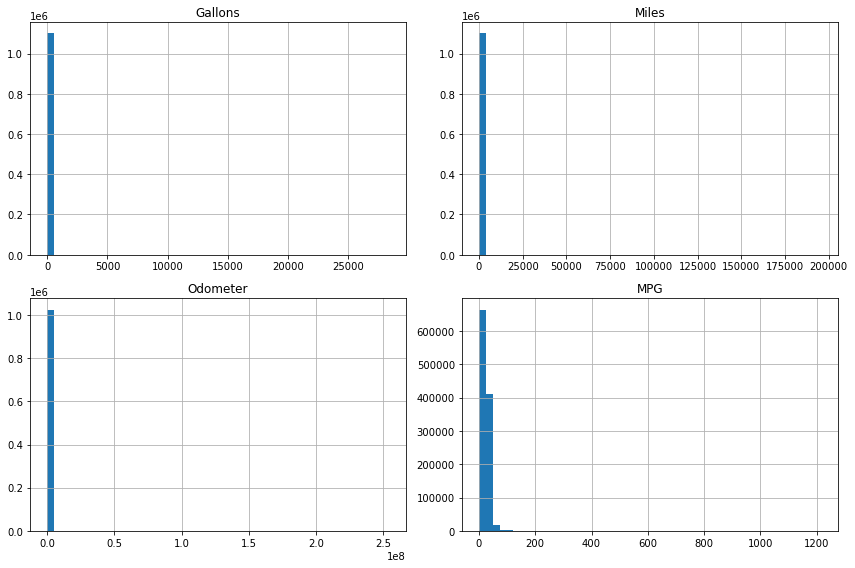

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['gallons_clean'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Gallons')

df['miles_clean'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Miles')

df['odometer_clean'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Odometer')

df['mpg_clean'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('MPG')

plt.tight_layout()
plt.show()

### Question 5: Statistical description of numeric columns
Summary statistics for `gallons_clean`, `miles_clean`, `odometer_clean`, and `mpg_clean`.

In [13]:
cols = ['gallons_clean', 'miles_clean', 'odometer_clean', 'mpg_clean']

desc = df[cols].describe()
mode_row = df[cols].mode().iloc[0]
desc.loc['mode'] = mode_row

print(desc)

       gallons_clean   miles_clean  odometer_clean     mpg_clean
count   1.100660e+06  1.100660e+06    1.025716e+06  1.100660e+06
mean    1.280107e+01  2.694896e+02    1.039960e+05  2.216332e+01
std     7.447210e+01  7.257092e+02    3.405252e+05  1.574305e+01
min     0.000000e+00  0.000000e+00    0.000000e+00  0.000000e+00
25%     8.990000e+00  1.814000e+02    4.592000e+04  1.560000e+01
50%     1.195400e+01  2.670580e+02    9.188200e+04  2.180000e+01
75%     1.493900e+01  3.427692e+02    1.469220e+05  2.850000e+01
max     2.838000e+04  1.953212e+05    2.543621e+08  1.214300e+03
mode    1.056700e+01  0.000000e+00    1.000000e+00  0.000000e+00


# 2 Feature Engineering

## Creating New Features

### Question 1: Extract currency
Before extracting currency values, we first inspect `cost_per_gallon` to understand 
what currency symbols actually appear in the raw data.

In [14]:
import re

sample = df['cost_per_gallon'].dropna().astype(str)
prefixes = sample.str.extract(r'^([^\d]+)')[0].value_counts()
print(prefixes.head(30))

$      739869
£       86459
€       58574
CA$     46398
R       36144
AU$     23197
RM       8572
NZ$      7543
R$       6307
zł       5283
Skr      4897
Rs       4737
₱        4176
฿        4132
Ft       3790
Dkr      3788
RUB      3732
MXN      3280
Nkr      2978
BGN      2852
S$       2628
Kč       2365
RON      2072
₪        1820
₩        1727
HK$      1621
NT$      1597
kn       1415
Fr.      1381
AR$      1286
Name: 0, dtype: int64


### Question 1: Create currency column
We extract the currency symbol/code as all non-digit characters at the start of 
`cost_per_gallon`. We use `cost_per_gallon` rather than `total_spent` since both 
should carry the same currency, but this could equally be validated against both.

In [15]:
df['currency'] = df['cost_per_gallon'].dropna().astype(str).str.extract(r'^([^\d]+)')[0]

print(df['currency'].value_counts())

$      739869
£       86459
€       58574
CA$     46398
R       36144
        ...  
CV$        11
KGS         9
L$          9
IQD         8
YR          4
Name: currency, Length: 121, dtype: int64


In [16]:
print(df['currency'].unique())

[nan '$' '£' 'RON' '€' 'zł' 'AU$' '₩' 'Ft' 'NZ$' 'Nkr' 'R$' 'CA$' 'RUB'
 '₪' 'Rp' 'RM' 'R' 'Skr' 'AR$' 'TL' 'din.' 'Ikr' '฿' 'CN¥' 'HK$' 'Dkr' '₡'
 '₴' 'IRR' 'S$' 'Rs' 'BGN' '¥' 'AED' 'MKD' '₱' 'BD' 'CL$' 'EC$' '$U' 'LE'
 'MXN' 'CO$' 'CFPF' 'Kč' 'kn' 'JD' 'FCFA' 'NT$' 'BN$' 'RD$' 'S/.' 'J$'
 'PKRs' 'Ksh' 'GY$' 'KM' 'Fr.' 'CFA' 'MDL' 'MMK' 'N$' '₦' 'ZWL' 'USh'
 'MURs' 'BYN' 'TT$' 'KD' 'B/.' 'Bs.F.' 'SLRs' 'SR' 'GTQ' 'QR' 'Br' 'C$'
 'BWP' 'GH₵' 'Tk' 'SR$' 'man.' 'KHR' 'BZ$' 'Bds$' 'Kz' 'NPRs' 'OMR' '₲'
 'LB£' 'HNL' 'AMD' 'GEL' '₮' 'MTn' 'ZMW' 'SH£' '₫' 'RWF' 'MGA' 'DT' 'VT'
 'MOP$' 'TMT' 'SY£' 'BS$' 'Af' 'ALL' 'DA' 'TSh' 'KY$' 'Bs' 'NAf.' 'KZT'
 'YR' 'MAD' 'CV$' 'IQD' 'CU$' 'KGS' 'L$']


In [17]:
print(len(df))
print(df['currency'].isna().sum())
print(df['cost_per_gallon'].isna().sum())

1174870
80760
80760


In [19]:
df[['cost_per_gallon', 'currency']].head(10)

,cost_per_gallon,currency
0,NaN,NaN
1,$5.599,$
2,£5.45,£
3,£5.11,£
4,$3.029,$
5,$3.739,$
6,$4.639,$
7,$2.929,$
8,NaN,NaN
9,$1.999,$


In [20]:
df.head()

,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url,date_fueled_clean,gallons_clean,miles_clean,odometer_clean,mpg_clean,currency
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...,2022-04-07,NaN,NaN,73370.0,NaN,NaN
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150,2012-11-07,12.120,382.9920,11983.0,31.6,$
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...,2012-09-22,7.991,227.7435,98233.0,28.5,£
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233,2019-05-04,10.575,494.9100,163802.0,46.8,£
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...,2022-02-15,11.651,244.4000,NaN,21.0,$


### Question 2: Extract numeric value from cost fields
We extract the numeric portion of `cost_per_gallon` and `total_spent`.

In [30]:
import numpy as np

def extract_amount(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'\d[\d.,]*', str(value))
    if not match:
        return np.nan
    number_str = match.group().replace(',', '')
    return float(number_str)

test_values = ['$5.599', 'RON16.69', 'Fr.1381', '£43.53', 'din.500']
for v in test_values:
    print(v, '->', extract_amount(v))

df['cost_per_gallon_value'] = df['cost_per_gallon'].apply(extract_amount)
df['total_spent_value'] = df['total_spent'].apply(extract_amount)

df[['cost_per_gallon', 'cost_per_gallon_value', 'total_spent', 'total_spent_value']].head(10)

$5.599 -> 5.599
RON16.69 -> 16.69
Fr.1381 -> 1381.0
£43.53 -> 43.53
din.500 -> 500.0


,cost_per_gallon,cost_per_gallon_value,total_spent,total_spent_value
0,NaN,NaN,NaN,NaN
1,$5.599,5.599,$67.86,67.86
2,£5.45,5.450,£43.53,43.53
3,£5.11,5.110,£54.00,54.00
4,$3.029,3.029,$35.29,35.29
5,$3.739,3.739,$12.76,12.76
6,$4.639,4.639,$41.96,41.96
7,$2.929,2.929,$43.82,43.82
8,NaN,NaN,NaN,NaN
9,$1.999,1.999,$5.42,5.42


### Question 3: Extract make, model, year, and user ID from URL
We split `user_url` on `/` and extract the last four segments, which consistently represent `make`, `model`, `year`, and `user_id` in that order. Indexing from the end of the list rather than the start, because the URL prefix length is consistent 
but not always the segment count (e.g. cases where make and model are merged, such as "kianival").

In [31]:
url_parts = df['user_url'].str.rstrip('/').str.split('/')
url_parts.head(10)

0    [https:, , www.somewebsite.com, suzuki, swift,...
1    [https:, , www.somewebsite.com, bmw, x3, 2009,...
2    [https:, , www.somewebsite.com, mercedes-benz,...
3    [https:, , www.somewebsite.com, bmw, 320d, 201...
4    [https:, , www.somewebsite.com, honda, passpor...
5    [https:, , www.somewebsite.com, volkswagen, pa...
6    [https:, , www.somewebsite.com, mazda, 3_sport...
7    [https:, , www.somewebsite.com, subaru, forest...
8    [https:, , www.somewebsite.com, kianival, 2009...
9    [https:, , www.somewebsite.com, lexus, rx350, ...
Name: user_url, dtype: object

In [32]:
url_parts = df['user_url'].str.rstrip('/').str.split('/')

df['make'] = url_parts.str[-4]
df['model'] = url_parts.str[-3]
df['year'] = url_parts.str[-2]
df['user_id'] = url_parts.str[-1]

df[['user_url', 'make', 'model', 'year', 'user_id']].head(10)

,user_url,make,model,year,user_id
0,https://www.somewebsite.com/suzuki/swift/2015/...,suzuki,swift,2015,674857
1,https://www.somewebsite.com/bmw/x3/2009/461150,bmw,x3,2009,461150
2,https://www.somewebsite.com/mercedes-benz/e300...,mercedes-benz,e300,1998,133501
3,https://www.somewebsite.com/bmw/320d/2010/247233,bmw,320d,2010,247233
4,https://www.somewebsite.com/honda/passport/201...,honda,passport,2019,1038865
5,https://www.somewebsite.com/volkswagen/passat/...,volkswagen,passat,2004,445811
6,https://www.somewebsite.com/mazda/3_sport/2010...,mazda,3_sport,2010,529810
7,https://www.somewebsite.com/subaru/forester/20...,subaru,forester,2020,1087864
8,https://www.somewebsite.com/kianival/2009/789684,www.somewebsite.com,kianival,2009,789684
9,https://www.somewebsite.com/lexus/rx350/2012/8...,lexus,rx350,2012,898688


### Question 3 (revised): Handle URLs with merged make/model
Some URLs have only 6 segments instead of 7 (e.g. "kianival" instead of separate "kia"/"nival"), meaning make and model were not separated at the source. For these rows, we mark `make` as missing and keep the merged string as `model`, rather than guessing the split.

In [33]:
url_parts = df['user_url'].str.rstrip('/').str.split('/')
num_parts = url_parts.str.len()

df['year'] = url_parts.str[-2]
df['user_id'] = url_parts.str[-1]

# Normal case: 7 parts, make and model are separate
normal_mask = num_parts == 7
df.loc[normal_mask, 'make'] = url_parts[normal_mask].str[-4]
df.loc[normal_mask, 'model'] = url_parts[normal_mask].str[-3]

# Short case: 6 parts, make/model merged - mark make as missing
short_mask = num_parts == 6
df.loc[short_mask, 'make'] = np.nan
df.loc[short_mask, 'model'] = url_parts[short_mask].str[-3]

print(f"Normal URLs (make/model separate): {normal_mask.sum()}")
print(f"Short URLs (make/model merged): {short_mask.sum()}")
print(f"Other lengths (unexpected): {(~normal_mask & ~short_mask).sum()}")

df[['user_url', 'make', 'model', 'year', 'user_id']].head(10)

Normal URLs (make/model separate): 1169807
Short URLs (make/model merged): 4733
Other lengths (unexpected): 330


,user_url,make,model,year,user_id
0,https://www.somewebsite.com/suzuki/swift/2015/...,suzuki,swift,2015,674857
1,https://www.somewebsite.com/bmw/x3/2009/461150,bmw,x3,2009,461150
2,https://www.somewebsite.com/mercedes-benz/e300...,mercedes-benz,e300,1998,133501
3,https://www.somewebsite.com/bmw/320d/2010/247233,bmw,320d,2010,247233
4,https://www.somewebsite.com/honda/passport/201...,honda,passport,2019,1038865
5,https://www.somewebsite.com/volkswagen/passat/...,volkswagen,passat,2004,445811
6,https://www.somewebsite.com/mazda/3_sport/2010...,mazda,3_sport,2010,529810
7,https://www.somewebsite.com/subaru/forester/20...,subaru,forester,2020,1087864
8,https://www.somewebsite.com/kianival/2009/789684,NaN,kianival,2009,789684
9,https://www.somewebsite.com/lexus/rx350/2012/8...,lexus,rx350,2012,898688


In [36]:
df.head()

,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url,date_fueled_clean,...,miles_clean,odometer_clean,mpg_clean,currency,cost_per_gallon_value,total_spent_value,make,model,year,user_id
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...,2022-04-07,...,NaN,73370.0,NaN,NaN,NaN,NaN,suzuki,swift,2015,674857
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150,2012-11-07,...,382.9920,11983.0,31.6,$,5.599,67.86,bmw,x3,2009,461150
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...,2012-09-22,...,227.7435,98233.0,28.5,£,5.450,43.53,mercedes-benz,e300,1998,133501
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233,2019-05-04,...,494.9100,163802.0,46.8,£,5.110,54.00,bmw,320d,2010,247233
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...,2022-02-15,...,244.4000,NaN,21.0,$,3.029,35.29,honda,passport,2019,1038865


## Proper Measurement Standards

### Question 1: Feature: litres_filled
We convert `gallons_clean` to litres. Since gallon size differs by country (US gallon = 3.785 L, UK/Imperial gallon = 4.546 L), we use the `currency` column as a proxy to decide which conversion to apply — currencies associated with UK-gallon-using countries (e.g. `£`) use the Imperial conversion; all others default to the US gallon.

In [37]:
US_GALLON_TO_LITRES = 3.78541
UK_GALLON_TO_LITRES = 4.54609

# Currencies from countries that use UK/Imperial gallons
uk_gallon_currencies = ['£']

df['litres_filled'] = df['gallons_clean'] * US_GALLON_TO_LITRES
df.loc[df['currency'].isin(uk_gallon_currencies), 'litres_filled'] = (
    df.loc[df['currency'].isin(uk_gallon_currencies), 'gallons_clean'] * UK_GALLON_TO_LITRES
)

df[['gallons_clean', 'currency', 'litres_filled']].head(10)

,gallons_clean,currency,litres_filled
0,NaN,NaN,NaN
1,12.120,$,45.879169
2,7.991,£,36.327805
3,10.575,£,48.074902
4,11.651,$,44.103812
5,3.413,$,12.919604
6,9.044,$,34.235248
7,14.962,$,56.637304
8,NaN,NaN,NaN
9,2.710,$,10.258461


### Question 2 km_driven and litres_per_100km
We convert `miles_clean` to kilometres using the standard conversion factor, then compute fuel efficiency in litres per 100km using `litres_filled` and `km_driven`.

In [38]:
miles_to_km = 1.609344

df['km_driven'] = df['miles_clean'] * miles_to_km
df['litres_per_100km'] = df['litres_filled'] / (df['km_driven'] / 100)

df[['miles_clean', 'km_driven', 'gallons_clean', 'litres_filled', 'litres_per_100km']].head(10)

,miles_clean,km_driven,gallons_clean,litres_filled,litres_per_100km
0,NaN,NaN,NaN,NaN,NaN
1,382.9920,616.365877,12.120,45.879169,7.443496
2,227.7435,366.517635,7.991,36.327805,9.911612
3,494.9100,796.480439,10.575,48.074902,6.035917
4,244.4000,393.323674,11.651,44.103812,11.213109
5,98.9770,159.288041,3.413,12.919604,8.110844
6,266.7980,429.369761,9.044,34.235248,7.973372
7,408.4626,657.356835,14.962,56.637304,8.615915
8,NaN,NaN,NaN,NaN,NaN
9,0.0000,0.000000,2.710,10.258461,inf


In [39]:
inf_count = np.isinf(df['litres_per_100km']).sum()
print(f"Infinite litres_per_100km values: {inf_count}")

Infinite litres_per_100km values: 134218


### Handling infinite litres_per_100km values
Rows where `miles_clean` is 0 produce an infinite `litres_per_100km` value (division by zero), which is not a meaningful measurement. We convert these to `NaN` rather than leaving them as `inf`, since `inf` would distort any later statistics, plots, or outlier-detection logic.

In [40]:
inf_mask = np.isinf(df['litres_per_100km'])
df.loc[inf_mask, 'litres_per_100km'] = np.nan

print(f"Remaining infinite values: {np.isinf(df['litres_per_100km']).sum()}")
print(f"Missing litres_per_100km: {df['litres_per_100km'].isna().sum()}")

Remaining infinite values: 0
Missing litres_per_100km: 208997


In [41]:
df.head()

,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url,date_fueled_clean,...,currency,cost_per_gallon_value,total_spent_value,make,model,year,user_id,litres_filled,km_driven,litres_per_100km
0,"Cooling System, Heating System, Lights, Spark ...",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/...,2022-04-07,...,NaN,NaN,NaN,suzuki,swift,2015,674857,NaN,NaN,NaN
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150,2012-11-07,...,$,5.599,67.86,bmw,x3,2009,461150,45.879169,616.365877,7.443496
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300...,2012-09-22,...,£,5.450,43.53,mercedes-benz,e300,1998,133501,36.327805,366.517635,9.911612
3,May 4 2019,May 4 2019,"163,802",10.575,£5.11,£54.00,46.8,NaN,https://www.somewebsite.com/bmw/320d/2010/247233,2019-05-04,...,£,5.110,54.00,bmw,320d,2010,247233,48.074902,796.480439,6.035917
4,Feb 15 2022,Feb 15 2022,NaN,11.651,$3.029,$35.29,21.0,244.4,https://www.somewebsite.com/honda/passport/201...,2022-02-15,...,$,3.029,35.29,honda,passport,2019,1038865,44.103812,393.323674,11.213109
